# Radio Bias Systematics

Investigates whether the choice of point source mask (fiducial vs. unWISE catalog) introduces a bias in the measured CMB temperature–galaxy cross-power spectrum $C_\ell^{Tg}$.

Two instrument configurations are compared:
- **SKA** forecasted maps (cells below the first plot)
- **Planck** maps, with comparison to McCarthy et al. (arXiv:2406.02546) measurements

The signal curves show the expected $C_\ell^{Tg}$ from dark photon mixing at the stated $\epsilon$ and mass.

In [23]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import astropy.units as un
from astropy.cosmology import Planck18
import astropy.constants as const
import seaborn as sns
import numpy as np
from scipy.integrate import simpson, quad, dblquad
from scipy.interpolate import interp1d, griddata
from scipy.optimize import fsolve
import pymaster as nmt
from tqdm import tqdm

from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

import healpy as hp
import scipy.special as sp

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings

from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
unwise_auto_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/clean_auto_Cls_binning150.npy")
unwise_auto_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/covariance_clean_PP_binning150_K22.npy')

unwise_cross_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/cross_Pg_Cls_binning150_K22.npy")
unwise_cross_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/covariance_clean_gP_binning150_K22.npy")


original_auto_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/clean_auto_Cls_binning150.npy")
original_auto_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/covariance_clean_PP_binning150_K22.npy')

original_cross_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/cross_Pg_Cls_binning150_K22.npy")
original_cross_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/covariance_clean_gP_binning150_K22.npy")

ells = nmt.NmtBin.from_nside_linear(2048, 150).get_effective_ells()

In [25]:
# Unit conversion prefactors for C_ell^{Tg}.
# mc_prefac: converts from natural units to μK, matching the McCarthy et al. convention
#   (uses 353 GHz reference frequency; x = hν/kT_CMB is the dimensionless frequency)
TCMB_eV = 0.000235264       # CMB temperature in eV
x = 2 * np.pi * 0.000232349 / TCMB_eV  # x = hν/kT at 353 GHz (ℏν = 2.323e-4 eV)
mc_prefac = TCMB_eV * x**2 / (1 - np.exp(-x))

# new_prefac: ℏω at the 410 MHz analysis frequency, converts signal to mK
new_prefac = 2 * np.pi * 410e6 * 6.58212e-16

In [26]:
signal_ls = np.load("/projectnb/darkcosmo/dark_photon_project/dark_photons_radio_sky/notebooks_for_paper/data/ls.npy")
cross_signal = np.load("/projectnb/darkcosmo/dark_photon_project/dark_photons_radio_sky/notebooks_for_paper/data/Cl_gP_mA5.623e-13_modelK22.npy")

## Planck comparison

Load ILC auto and cross spectra for Planck (fiducial and unWISE point source masks), then compare with the digitized McCarthy et al. measurements.

In [27]:
unwise_auto_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/clean_auto_Cls_binning150.npy")
unwise_auto_Planck_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/covariance_clean_PP_binning150_K22.npy')

unwise_cross_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/cross_Pg_Cls_binning150_K22.npy")
unwise_cross_Planck_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/covariance_clean_gP_binning150_K22.npy")


original_auto_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/clean_auto_Cls_binning150.npy")
original_auto_Planck_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/covariance_clean_PP_binning150_K22.npy')

original_cross_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/cross_Pg_Cls_binning150_K22.npy")
original_cross_Planck_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/covariance_clean_gP_binning150_K22.npy")
ells = nmt.NmtBin.from_nside_linear(2048, 150).get_effective_ells()

In [28]:
# digitized data from McCarthy et al, arXiv:2406.02546
mccarthy_ells = np.array([227.5424868535669,
                377.8671068963559,
                530.9851126361218,
                681.2060911601186,
                828.6682311600691, 
                978.6819266464809,
                1128.7301693058237,
                1278.911665346471,
                1429.6163042914989, 
                1579.6497410195855, 
                1728.9280752536126,
                1879.1836009505403,
                ])
mccarthy_lCl_Tg_uK = np.array([0.00007100085627635759, 
                  0.00004516450623453082, 
                  0.00002490209577956924, 
                  0.000013699928191233365, 
                  -0.000007954239801797979, 
                  0.00001011195751684786, 
                  0.000023300094017663416, 
                  0.00001767285307827644,
                  -0.0000618221659596835,
                  -0.00004654343196551215,
                  0.00007535577418980703,
                  0.00005927554578364085
                  ])
upper_Mccarthy_error = np.array([0.00008867200782766628, 
                                 0.00005011225066091601, 
                                 0.000031156656435443123, 
                                 0.000022935833095309477, 
                                 0.000003980569434931282, 
                                 0.000023065084047337785, 
                                 0.000040983695570731815, 
                                 0.0000425647884186895, 
                                 -0.00002750178905425811, 
                                 0.0000037181007497382173, 
                                 0.00014999414685047284, 
                                 0.00017958236734702215
                                ]) - mccarthy_lCl_Tg_uK
lower_Mccarthy_error = mccarthy_lCl_Tg_uK - np.array([0.0000534321159070040, 
                                 0.0000400769555159653, 
                                 0.00001785372532936736, 
                                 0.00000426584711165874, 
                                 -0.00001842480211884726, 
                                 -0.00000330673807776512, 
                                 0.000005742150824596017, 
                                 -0.000005979026303332699,
                                 -0.00009564745276189474, 
                                 -0.0000959337221339063, 
                                 0.0000013330735914662904, 
                                 -0.000060098151912591847
                                 ]) 

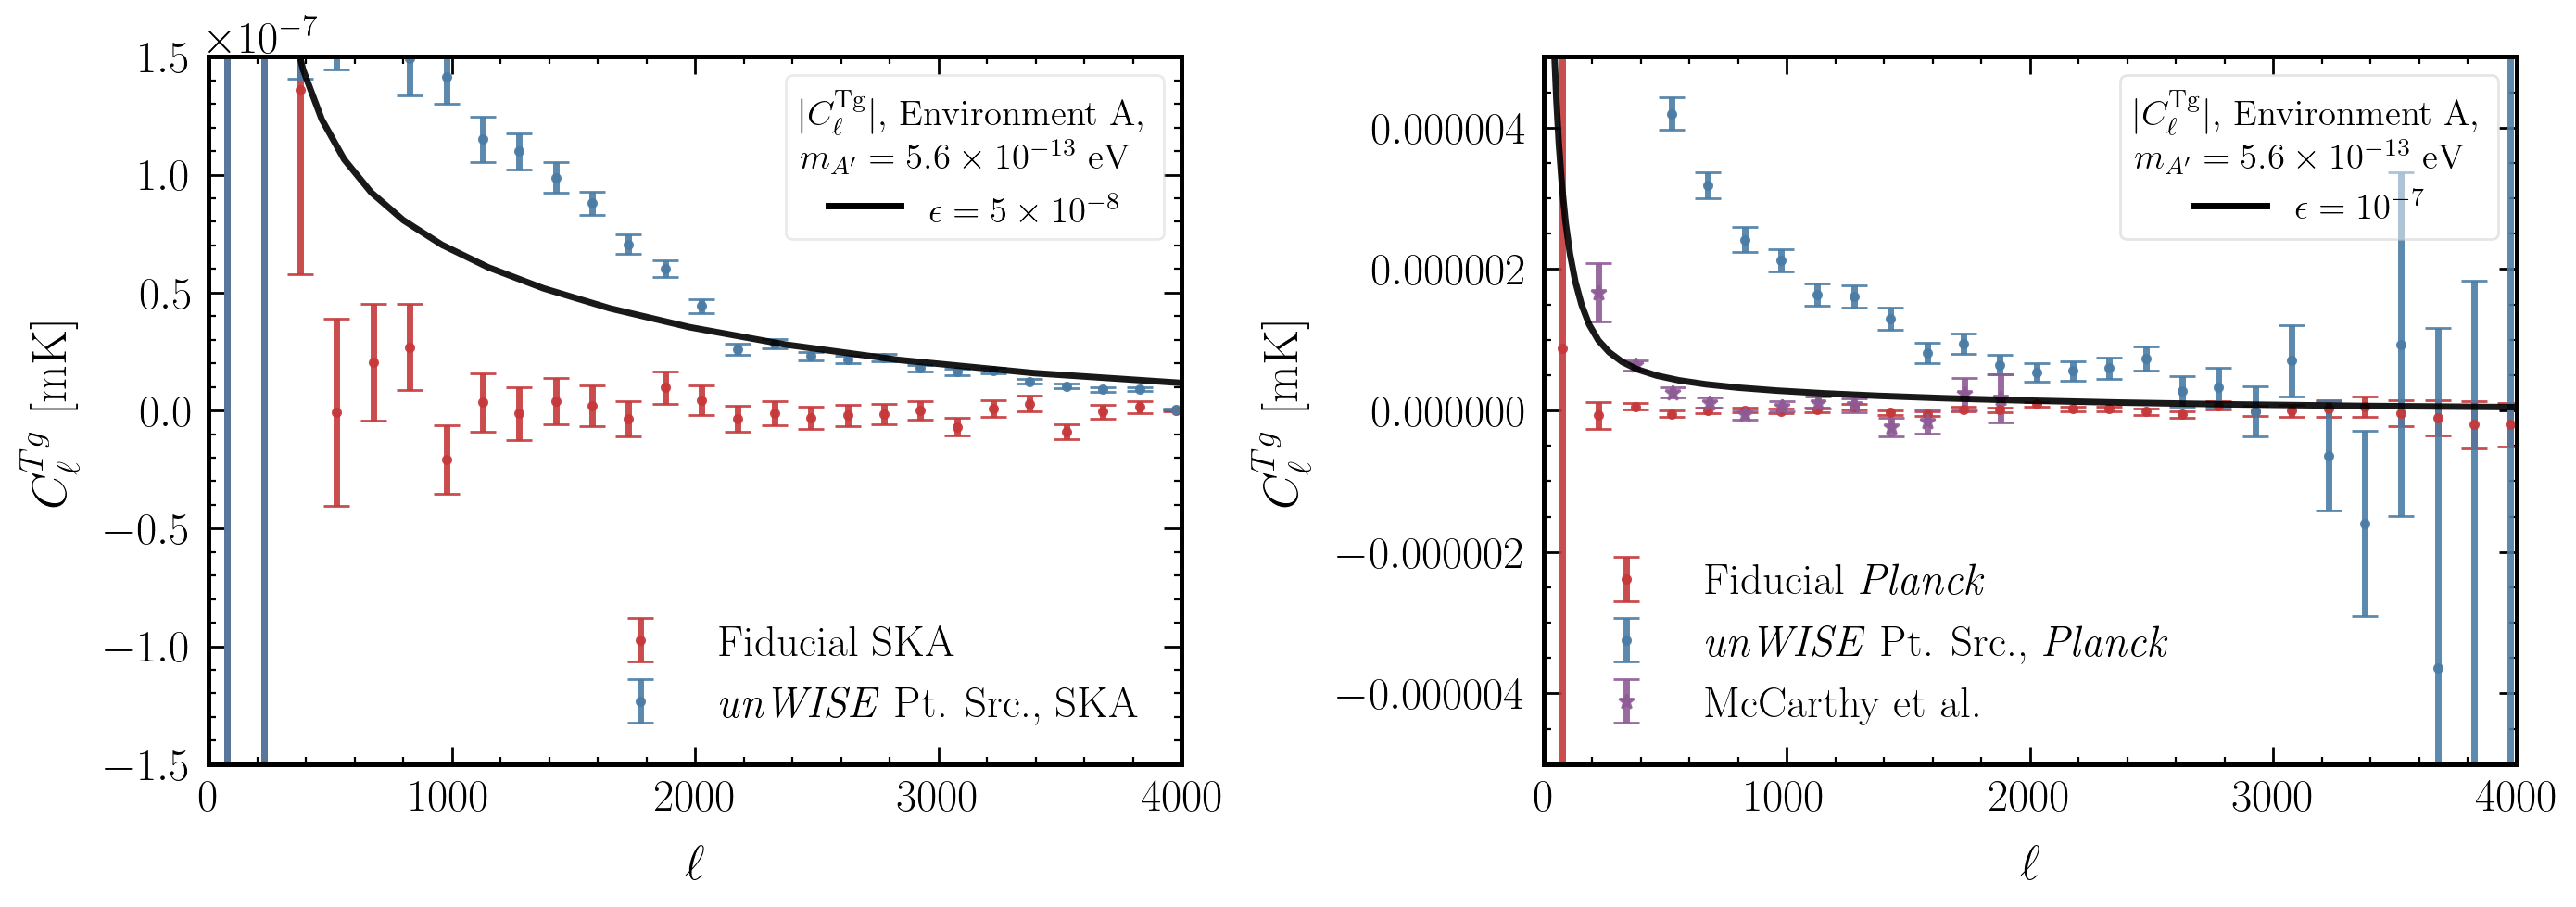

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel (a): SKA ---
ax = axes[0]
ax.errorbar(ells, new_prefac**-1 * original_cross_Cls,
            yerr=new_prefac**-1 * np.sqrt(np.diag(original_cross_cov)),
            fmt=".", label="Fiducial SKA")
ax.errorbar(ells, new_prefac**-1 * unwise_cross_Cls,
            yerr=new_prefac**-1 * np.sqrt(np.diag(unwise_cross_cov)),
            fmt=".", label=r"\textit{unWISE} Pt. Src., SKA")
ax.errorbar(signal_ls, (2.73e3) * (5e-8)**2 * new_prefac**-1 * cross_signal, fmt="k-")

big_eps_line_a = Line2D([0,1],[0,1], linestyle='-', color='k')
legend2a = ax.legend([big_eps_line_a], [r"$\epsilon=5\times10^{-8}$"],
                     fontsize=14, loc="upper right", frameon=True,
                     title=r"$|C_\ell^{\rm Tg}|$, Environment A," + "\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)
ax.legend()
ax.add_artist(legend2a)
ax.set_ylim(-1.5e-7, 1.5e-7)
ax.set_xlim(0, 4000)
ax.set_ylabel(r"$C_\ell^{Tg}$ [mK]")
ax.set_xlabel(r"$\ell$")
# ax.set_title("(a) SKA")

# --- Panel (b): Planck, with McCarthy et al. comparison ---
ax = axes[1]
ax.errorbar(ells, original_cross_Planck_Cls * mc_prefac / new_prefac,
            yerr=np.sqrt(np.diag(original_cross_Planck_cov)) * mc_prefac / new_prefac,
            fmt=".", label=r"Fiducial \textit{Planck}")
ax.errorbar(ells, unwise_cross_Planck_Cls * mc_prefac / new_prefac,
            yerr=np.sqrt(np.diag(unwise_cross_Planck_cov)) * mc_prefac / new_prefac,
            fmt=".", label=r"\textit{unWISE} Pt. Src., \textit{Planck}")
# McCarthy et al. data digitized from arXiv:2406.02546; convert from ℓC_ℓ [μK] → C_ℓ [mK]
ax.errorbar(mccarthy_ells, (1e-3) * mccarthy_lCl_Tg_uK / mccarthy_ells * mc_prefac / new_prefac,
            yerr=np.array([upper_Mccarthy_error, lower_Mccarthy_error]) / mccarthy_ells * mc_prefac / new_prefac * 1e-3,
            fmt="*", color=cols_default[3], label="McCarthy et al.")
ax.errorbar(signal_ls, (2.73e3) * (1e-7)**2 * new_prefac**-1 * cross_signal, fmt="k-")

big_eps_line_b = Line2D([0,1],[0,1], linestyle='-', color='k')
legend2b = ax.legend([big_eps_line_b], [r"$\epsilon=10^{-7}$"],
                     fontsize=14, loc="upper right", frameon=True,
                     title=r"$|C_\ell^{\rm Tg}|$, Environment A," + "\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14, framealpha=0.5)
ax.legend(loc="lower left")
ax.add_artist(legend2b)
ax.set_ylim(-50e-7, 50e-7)
ax.set_xlim(0, 4000)
ax.set_ylabel(r"$C_\ell^{Tg}$ [mK]")
ax.set_xlabel(r"$\ell$")
# ax.set_title("(b) Planck")

plt.tight_layout()
plt.savefig("plots/radio_bias_comparison.pdf", bbox_inches='tight')